In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
data=pd.read_csv('/content/student_exam_scores.csv')

In [49]:
data.isnull().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [51]:
data.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [52]:
data=data.drop_duplicates()

In [53]:
data=data.drop("student_id", axis=1)

In [54]:
X=data.drop("exam_score", axis=1)
y=data["exam_score"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Training Set Matrics:
MAE: 2.29
MSE: 7.20
RMSE: 2.68
R² Score: 0.84

Test Set Matrics:
MAE: 2.31
MSE: 7.76
RMSE: 2.79
R² Score: 0.85


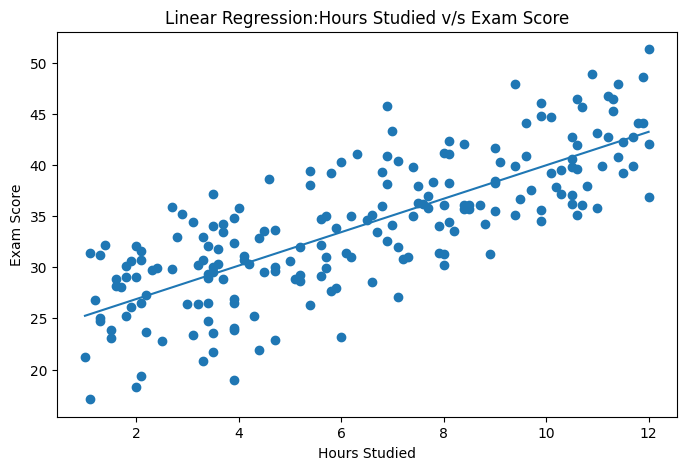

In [56]:
model=LinearRegression()
model.fit(X_train, y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae=mean_absolute_error(y_true, y_pred)
    mse=mean_squared_error(y_true, y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Matrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")
X_vis=data[['hours_studied']]
y_vis=data['exam_score']
vis_model=LinearRegression()
vis_model.fit(X_vis, y_vis)
y_vis_pred=vis_model.predict(X_vis)
sorted_idx=X_vis['hours_studied'].argsort()
X_sorted=X_vis.iloc[sorted_idx]
y_sorted=y_vis_pred[sorted_idx]
plt.figure(figsize=(8, 5))
plt.scatter(X_vis, y_vis)
plt.plot(X_sorted, y_sorted)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression:Hours Studied v/s Exam Score")
plt.show()

Mean Squared Error: 7.76
R-squared Score: 0.85
Coefficients: [('hours_studied', np.float64(1.5493412577240118)), ('sleep_hours', np.float64(0.8841564250608489)), ('attendance_percent', np.float64(0.10894945971852166)), ('previous_scores', np.float64(0.1830335511253317))]
Intercept: -2.20


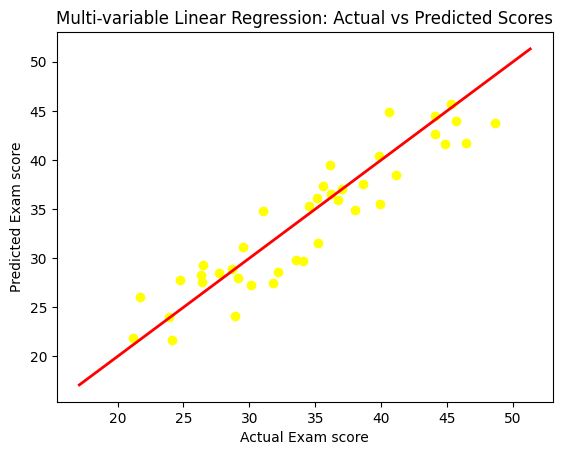

In [57]:
X = data[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]
y = data["exam_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")
print(f"Coefficients: {list(zip(X.columns, lr_model.coef_))}")
print(f"Intercept: {lr_model.intercept_:.2f}")
plt.scatter(y_test, y_pred, color='yellow')
plt.xlabel('Actual Exam score')
plt.ylabel('Predicted Exam score')
plt.title('Multi-variable Linear Regression: Actual vs Predicted Scores')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2)
plt.show()

In [58]:
X=data.drop("exam_score", axis=1)
y=data["exam_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model=DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae=mean_absolute_error(y_true, y_pred)
    mse=mean_squared_error(y_true, y_pred)
    rmse=np.sqrt(mse)
    r2=r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Matrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")
param_grid={
    'max_depth': [None] + list(np.arange(1, 21)),
    'min_samples_split': np.arange(2, 21),
    'min_samples_leaf': np.arange(1, 21)
}
grid = GridSearchCV(
      DecisionTreeRegressor(random_state=42),
      param_grid,
      cv=5,
      scoring='r2',
      n_jobs=-1
 )
grid.fit(X_train, y_train)
best_tree=grid.best_estimator_
y_test_pred_best=best_tree.predict(X_test)
print("\nBest hyperparameters found:", grid.best_params_)
evaluate_model(y_train, best_tree.predict(X_train), "Training Set (Best Tree)")
evaluate_model(y_test, y_test_pred_best, "Test Set (Best Tree)")


Training Set Matrics:
MAE: 0.00
MSE: 0.00
RMSE: 0.00
R² Score: 1.00

Test Set Matrics:
MAE: 4.25
MSE: 25.65
RMSE: 5.06
R² Score: 0.52

Best hyperparameters found: {'max_depth': np.int64(4), 'min_samples_leaf': np.int64(3), 'min_samples_split': np.int64(9)}

Training Set (Best Tree) Matrics:
MAE: 2.21
MSE: 7.64
RMSE: 2.76
R² Score: 0.83

Test Set (Best Tree) Matrics:
MAE: 3.84
MSE: 18.93
RMSE: 4.35
R² Score: 0.64


In [59]:
data.columns

Index(['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores',
       'exam_score'],
      dtype='object')

In [60]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = data.drop("exam_score", axis=1)
y = data["exam_score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
evaluate_model(y_train, y_train_pred, "Training Set")
evaluate_model(y_test, y_test_pred, "Test Set")
param_grid = {
     'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
y_train_pred_best = best_rf.predict(X_train)
y_test_pred_best = best_rf.predict(X_test)
print("\nBest hyperparameters:", grid.best_params_)
evaluate_model(y_train, y_train_pred_best, "Training Set")
evaluate_model(y_test, y_test_pred_best, "Test Set")


Training Set Metrics:
MAE: 1.03
MSE: 1.62
RMSE: 1.27
R² Score: 0.96

Test Set Metrics:
MAE: 2.97
MSE: 11.03
RMSE: 3.32
R² Score: 0.79

Best hyperparameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Training Set Metrics:
MAE: 1.52
MSE: 3.73
RMSE: 1.93
R² Score: 0.92

Test Set Metrics:
MAE: 2.84
MSE: 10.51
RMSE: 3.24
R² Score: 0.80
